In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import torch.optim as optim

from torch.utils.data import DataLoader, TensorDataset, random_split
from torchvision import datasets, transforms
from PIL import Image

In [79]:
train_data = datasets.MNIST(
    root='data',
    train=True,
    transform=transforms.ToTensor(),
    download=True
)

test_data = datasets.MNIST(
    root='data',
    train=False,
    transform=transforms.ToTensor(),
    download=True
)

In [82]:
loaders = {
    'train': DataLoader(train_data, batch_size=100, shuffle=True, num_workers=1),
    'test': DataLoader(test_data, batch_size=100, shuffle=False, num_workers=1)
}

In [83]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.conv1 = nn.Conv2d(1, 10, kernel_size=5)
        self.conv2 = nn.Conv2d(10, 20, kernel_size=5)
        self.conv2_drop = nn.Dropout2d()
        self.fc1 = nn.Linear(320, 50)
        self.fc2 = nn.Linear(50, 10)
    
    def forward(self, x):
        x = F.relu(F.max_pool2d(self.conv1(x), 2))
        x = F.relu(F.max_pool2d(self.conv2_drop(self.conv2(x)), 2))
        x = x.view(-1, 320)
        x = F.relu(self.fc1(x))
        x = F.dropout(x, training=self.training)
        x= self.fc2(x)

        return F.softmax(x)

In [84]:
model = CNN()
optimizer = optim.Adam(model.parameters(), lr=0.001)

loss_fn = nn.CrossEntropyLoss()

def train(epoch):
    model.train()
    for batch_idx, (data, target) in enumerate(loaders['train']):
        optimizer.zero_grad()
        output = model(data)
        loss = loss_fn(output, target)
        loss.backward()
        optimizer.step()
        if batch_idx % 20 == 0:
            print(f"Train epoch: {epoch} [{batch_idx * len(data)} / {len(loaders['train'].dataset)}]")

def test():
    model.eval()
    test_loss = 0
    correct = 0

    with torch.no_grad():
        for data, target in loaders['test']:
            output = model(data)
            test_loss += loss_fn(output, target).item()
            pred = output.argmax(dim=1, keepdim = True)
            correct += pred.eq(target.view_as(pred)).sum().item()
    
    test_loss /= len(loaders['test'].dataset)
    print(f"\nTest Set: Average Loss: {test_loss:.4f}, Accuracy: {correct/ len(loaders['test'].dataset)}")

In [85]:
for epoch in range(1, 11):
    train(epoch)
    test()

/var/folders/1c/tg2ygc_d7gnbq1cbq5yfq6500000gn/T/ipykernel_11213/3070799298.py:19: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return F.softmax(x)


Train epoch: 1 [0 / 60000]
Train epoch: 1 [2000 / 60000]
Train epoch: 1 [4000 / 60000]
Train epoch: 1 [6000 / 60000]
Train epoch: 1 [8000 / 60000]
Train epoch: 1 [10000 / 60000]
Train epoch: 1 [12000 / 60000]
Train epoch: 1 [14000 / 60000]
Train epoch: 1 [16000 / 60000]
Train epoch: 1 [18000 / 60000]
Train epoch: 1 [20000 / 60000]
Train epoch: 1 [22000 / 60000]
Train epoch: 1 [24000 / 60000]
Train epoch: 1 [26000 / 60000]
Train epoch: 1 [28000 / 60000]
Train epoch: 1 [30000 / 60000]
Train epoch: 1 [32000 / 60000]
Train epoch: 1 [34000 / 60000]
Train epoch: 1 [36000 / 60000]
Train epoch: 1 [38000 / 60000]
Train epoch: 1 [40000 / 60000]
Train epoch: 1 [42000 / 60000]
Train epoch: 1 [44000 / 60000]
Train epoch: 1 [46000 / 60000]
Train epoch: 1 [48000 / 60000]
Train epoch: 1 [50000 / 60000]
Train epoch: 1 [52000 / 60000]
Train epoch: 1 [54000 / 60000]
Train epoch: 1 [56000 / 60000]
Train epoch: 1 [58000 / 60000]

Test Set: Average Loss: 0.0152, Accuracy: 0.9377
Train epoch: 2 [0 / 60000]
T

In [87]:
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
}, "model.pth")

In [ ]:
data, target = next(iter(loaders['test']))

idx = 5
image = data[idx].unsqueeze(0)
label = target[idx].item()

with torch.no_grad():
    output = model(image)
    pred = output.argmax(dim=1).item()

print("Actual:", label)
print("Predicted:", pred)

Actual: 1
Predicted: 1


/var/folders/1c/tg2ygc_d7gnbq1cbq5yfq6500000gn/T/ipykernel_11213/3070799298.py:19: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return F.softmax(x)


0.0 1.0 0.12413965910673141


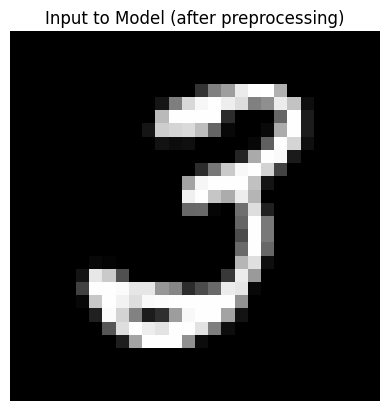

Predicted digit: 3, Confidence: 0.2320


/var/folders/1c/tg2ygc_d7gnbq1cbq5yfq6500000gn/T/ipykernel_11213/3070799298.py:19: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return F.softmax(x)


In [ ]:
model.eval()


transform = transforms.ToTensor()


image_path = "3.png"
image = Image.open(image_path).convert("L")



image = image.resize((28, 28), Image.NEAREST)


image = transform(image)  # [1, 28, 28], values [0,1]


if image.mean() > 0.5:
    image = 1 - image


print(image.min().item(), image.max().item(), image.mean().item())
# 5. Show image
plt.imshow(image.squeeze(), cmap='gray')
plt.title("Input to Model (after preprocessing)")
plt.axis('off')
plt.show()

# 6. Add batch dimension
image = image.unsqueeze(0)  # [1, 1, 28, 28]

# 7. Predict
with torch.no_grad():
    output = model(image)
    pred = output.argmax(dim=1).item()

    probs = F.softmax(output, dim=1)
    confidence = probs.max().item()

print(f"Predicted digit: {pred}, Confidence: {confidence:.4f}")

In [95]:
for k, v in model.state_dict().items():
    print(k, v.abs().mean().item())
    break

conv1.weight 0.2867039144039154
